<a href="https://colab.research.google.com/github/DreanoLucas/ML_AIR_Attack/blob/main/KDD_Kamarul_day2_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2 — Supervised Learning & Linear Regression — Project KDD (NSL-KDD)

**Continues** yesterday's exploration notebook (`KDD_Kamarul.ipynb`). Yesterday we *explored* the
`KDDTrain+_20Percent` subset of NSL-KDD: statistics, boxplots, histograms, correlations, the
**log transformation**, dropping constant/redundant features, and a train/test split.

Today we build our **first supervised model**, following the **same structure** as the course
regression notebook (`02.regression/a.regression.ipynb`), applied to our dataset:

scatterplot → train/test split → **Ordinary Least Squares (OLS)** → evaluate (MSE / RMSE) →
log transform → model instability → multivariate regression → fix a bad model
(constant / collinear features) → **cross-validation**.

This notebook is **self-contained**: it re-loads the raw `KDDTrain__20Percent.txt`, redoes the small
amount of prep we need, and implements the OLS model inline (no course library / no internet needed).

## 0. Load libraries

In [ ]:
import pandas as pd               # dataframes (tables)
import numpy as np                # numerical operations / arange
import math                       # for sqrt
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats           # for p-values (t-distribution)
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.base import BaseEstimator, RegressorMixin

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (8,4)

## 1. Load the data and redo the essential prep

We start from the **raw** file so the notebook runs on its own. We rebuild only what today needs:
the binary target `is_attack` and the **log** versions of the heavily-skewed magnitude features
(exactly as yesterday). On Colab, drag `KDDTrain__20Percent.txt` into the file panel first.

In [ ]:
FILENAME = 'KDDTrain__20Percent.txt'
COL_NAMES = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack','level']

import os
if not os.path.exists(FILENAME):
    try:
        from google.colab import files
        up = files.upload(); FILENAME = list(up.keys())[0]
    except Exception:
        raise FileNotFoundError(f'{FILENAME} not found and not on Colab.')

df = pd.read_csv(FILENAME)
df.columns = COL_NAMES

# binary target (1 = attack, 0 = normal) -- the numeric value we will predict
df['is_attack'] = (df['attack'] != 'normal').astype(int)

# log(1+x) of the skewed magnitude features (same set as yesterday)
to_log = ['duration','src_bytes','dst_bytes','count','srv_count',
          'dst_host_count','dst_host_srv_count']
for c in to_log:
    df[c+'_log'] = np.log1p(df[c])

print('shape:', df.shape, '| attack rate:', round(df['is_attack'].mean(),3))
df[['same_srv_rate','src_bytes','src_bytes_log','is_attack']].head()

Saving KDDTrain+_20Percent.txt to KDDTrain+_20Percent.txt
shape: (25192, 51) | attack rate: 0.466


,same_srv_rate,src_bytes,src_bytes_log,is_attack
0,1.00,491,6.198479,0
1,0.08,146,4.990433,0
2,0.05,0,0.000000,1
3,1.00,232,5.451038,0
4,1.00,199,5.298317,0


## 2. Wait — isn't this a *classification* problem?

Yes. Our real goal (attack vs normal) is **classification**: the target is a *category*. Today's
lesson is **regression**, whose target is a *number*. So why apply regression here?

| | **Regression** | **Classification** |
|---|---|---|
| Target $y$ | a real number ($y\in\mathbb{R}$): resolution, price, delay | a category ($y\in\{$normal, attack$\}$, or DoS/Probe/...) |
| Model output | a continuous value | a class label (often via a probability) |
| Typical loss | MSE / RMSE | misclassification rate, cross-entropy |
| Example model | Linear Regression (today) | Logistic Regression (next lesson) |

The trick: our label is already coded as the **number** `is_attack` $\in\{0,1\}$. If we run linear
regression on it, the prediction $\hat y$ is a number we can read as a **score / pseudo-probability of
attack**. Thresholding it at 0.5 turns it into a crude classifier. This is the
**Linear Probability Model** — a legitimate stepping stone that lets us practise *every* tool from
today's slides (OLS, RMSE, p-values, collinearity, cross-validation) on our own data, and it sets up
**Logistic Regression** next lesson (which fixes linear regression's flaw of predicting values below 0
or above 1).

## 3. Look at the data first (scatterplot)

Before modelling, plot the target against the single feature most correlated with it (from
yesterday): `same_srv_rate`. Because `is_attack` is 0/1, the points sit on two horizontal lines — we
add a little vertical jitter *only for the plot* so the density is visible.

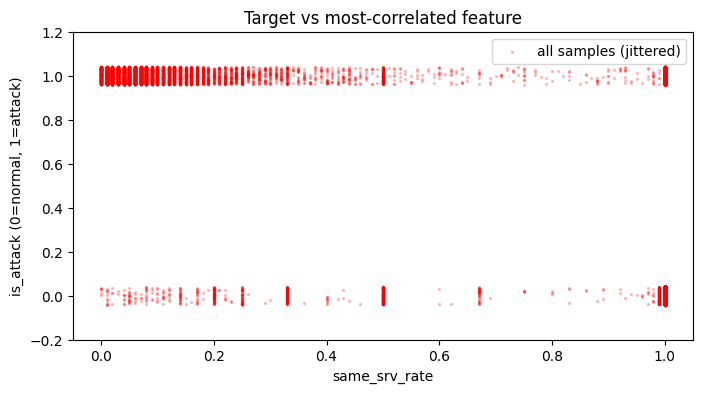

In [ ]:
fig, ax = plt.subplots()
jitter = (np.random.RandomState(0).rand(len(df)) - 0.5) * 0.08   # for visibility only
ax.scatter(df['same_srv_rate'], df['is_attack'] + jitter, color='red', s=2, alpha=0.2,
           label='all samples (jittered)')
ax.set(xlabel='same_srv_rate', ylabel='is_attack (0=normal, 1=attack)',
       ylim=[-0.2,1.2], title='Target vs most-correlated feature')
ax.legend(); plt.show()

Already visible **by hand**: connections with **low** `same_srv_rate` are mostly attacks
(top line), connections with **high** `same_srv_rate` are mostly normal (bottom line). So we expect a
line with a **negative slope**.

## 4. Train / test split (with reproducibility)

We fit the model on the **training set** only, and judge it on the **test set** it has never seen
(the *student-during-exam* analogy from the slides). Setting `random_state` makes the split — and
therefore every number below — **reproducible**.

In [ ]:
df_train, df_test = train_test_split(df, test_size=0.3, random_state=19)
print('training samples', df_train.shape[0], '| test samples', df_test.shape[0])

training samples 17634 | test samples 7558


## 5. The OLS model (built from the slides' normal equation)

The course downloads a helper `AndreaLinearRegression`. To stay self-contained — and because it is
more instructive — we implement it ourselves. It is exactly the slides:

$$h_\theta(\mathbf{x}^{(i)}) = \mathbf{x}^{(i)T}\!\cdot\theta, \qquad
J(\theta)=\tfrac1M\sum_i\big(y^{(i)}-h_\theta(\mathbf{x}^{(i)})\big)^2, \qquad
\boxed{\;\theta^* = (X^TX)^{-1}X^T\mathbf{y}\;}$$

The class adds the **p-value** of each coefficient (slides 22–30): under the null hypothesis
"this feature has no effect", each $\hat\theta_j$ is a Gaussian centred at 0; the p-value is the
probability of seeing a coefficient at least this large by chance. Small p-value ($\le 0.05$) ⇒ the
coefficient is **significant**.

In [ ]:
class OLSRegression(BaseEstimator, RegressorMixin):
    """Ordinary Least Squares via the normal equation, with p-values and R^2.
       Same .fit/.predict interface as scikit-learn so cross_val_score works."""
    def fit(self, X, y, column_names=None):
        X = np.asarray(X, float); y = np.asarray(y, float).ravel()
        M, N = X.shape
        Xb = np.hstack([np.ones((M,1)), X])          # prepend the bias column of 1s
        XtX_inv = np.linalg.inv(Xb.T @ Xb)           # (X^T X)^{-1}  -- fails if not invertible
        self.theta_ = XtX_inv @ Xb.T @ y             # normal equation  theta* = (X^TX)^-1 X^T y
        resid = y - Xb @ self.theta_                 # residuals  y - y_hat
        dof = M - (N + 1)
        sigma2 = (resid @ resid) / dof               # estimated variance of the noise
        se = np.sqrt(sigma2 * np.diag(XtX_inv))      # standard error of each coefficient
        tvals = self.theta_ / se
        self.pvalues_ = 2 * (1 - stats.t.cdf(np.abs(tvals), dof))
        self.r2_ = 1 - (resid @ resid) / (((y - y.mean())**2).sum())
        self.column_names_ = ['const'] + (list(column_names) if column_names is not None
                                          else [f'x{j+1}' for j in range(N)])
        return self

    def predict(self, X):
        X = np.asarray(X, float)
        return np.hstack([np.ones((X.shape[0],1)), X]) @ self.theta_

    def summary(self):
        print(f'{"feature":28s} {"coef":>12s} {"P>|t|":>10s}')
        for name, c, p in zip(self.column_names_, self.theta_, self.pvalues_):
            print(f'{name:28s} {c:12.4f} {p:10.4f}')
        print(f'R^2 = {self.r2_:.4f}')

## 6. Univariate Linear Regression

**Goal:** predict `is_attack` from a single feature, `same_srv_rate`.

In [ ]:
X_train = df_train[['same_srv_rate']].values     # sklearn wants a 2-D matrix
y_train = df_train['is_attack'].values
X_test  = df_test[['same_srv_rate']].values
y_test  = df_test['is_attack'].values

model = OLSRegression().fit(X_train, y_train, column_names=['same_srv_rate'])
model.summary()

feature                              coef      P>|t|
const                              1.0271     0.0000
same_srv_rate                     -0.8474     0.0000
R^2 = 0.5562


**Read the output.** The slope is negative — exactly the "by hand" intuition: more shared-service
traffic ⇒ less likely an attack. The p-value is ~0, so the dependency is **highly significant**. Now
predict on new values and evaluate on the test set.

same_srv_rate -> predicted attack-score:
   0.00  ->  1.027
   0.25  ->  0.815
   0.50  ->  0.603
   1.00  ->  0.180


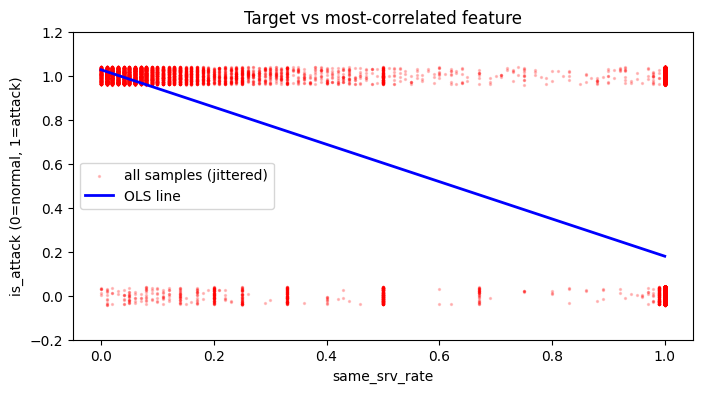

In [ ]:
# predict on a few new connections
new_samples = np.array([0.0, 0.25, 0.5, 1.0]).reshape(-1,1)
print('same_srv_rate -> predicted attack-score:')
for v, p in zip(new_samples.ravel(), model.predict(new_samples)):
    print(f'   {v:.2f}  ->  {p:.3f}')

# plot the fitted line over the data
interval = np.arange(0, 1.01, 0.01).reshape(-1,1)
ax.plot(interval, model.predict(interval), color='blue', linewidth=2, label='OLS line')
ax.legend(); fig

In [ ]:
y_pred = model.predict(X_test)
MSE = mean_squared_error(y_test, y_pred)
RMSE_one_feature = math.sqrt(MSE)
print('MSE :', round(MSE,4))
print('RMSE:', round(RMSE_one_feature,4), '  (in the same units as the 0/1 target)')

MSE : 0.1062
RMSE: 0.3258   (in the same units as the 0/1 target)


### Bridge to classification: threshold the score at 0.5

Because the target is 0/1, we can turn the regression score into a yes/no decision: predict
**attack** if $\hat y > 0.5$. The accuracy below is our first (crude) intrusion detector —
already much better than the ~53% you would get by always guessing "normal".

In [ ]:
y_class = (y_pred > 0.5).astype(int)
accuracy = (y_class == y_test).mean()
print('Accuracy of the 0.5-threshold classifier:', round(accuracy,4))

Accuracy of the 0.5-threshold classifier: 0.8674


## 7. The log transformation improves the model

Yesterday we saw `src_bytes` is uselessly correlated **raw** but strongly correlated **after log**.
Let's confirm it now *changes the model*, not just the correlation: fit `is_attack` on raw `src_bytes`
vs on `src_bytes_log`.

In [ ]:
for feat in ['src_bytes', 'src_bytes_log']:
    Xtr = df_train[[feat]].values; Xte = df_test[[feat]].values
    m = OLSRegression().fit(Xtr, y_train, column_names=[feat])
    rmse = math.sqrt(mean_squared_error(y_test, m.predict(Xte)))
    print(f'{feat:16s} ->  R^2 = {m.r2_:.4f}   TEST RMSE = {rmse:.4f}')

src_bytes        ->  R^2 = 0.0002   TEST RMSE = 0.5447
src_bytes_log    ->  R^2 = 0.5269   TEST RMSE = 0.3381


**Raw** `src_bytes` has $R^2\approx0$ — the line is flat, it explains nothing. **Logged**, the same
feature jumps to $R^2\approx0.53$. Same data, just a better representation: the outliers were hiding
the signal.

## 8. Instability — does the model depend on the split? (model variance)

If a model is **unstable**, perturbing the training set changes it completely (slide 44). Let's refit
the univariate model on several different splits and watch the coefficients.

In [ ]:
print('random_state   const     slope(same_srv_rate)')
for rs in [19, 2, 3, 7, 100]:
    tr, _ = train_test_split(df, test_size=0.3, random_state=rs)
    m = OLSRegression().fit(tr[['same_srv_rate']].values, tr['is_attack'].values,
                            column_names=['same_srv_rate'])
    print(f'   {rs:<10d}  {m.theta_[0]:.4f}   {m.theta_[1]:.4f}')

random_state   const     slope(same_srv_rate)
   19          1.0271   -0.8474
   2           1.0288   -0.8495
   3           1.0279   -0.8522
   7           1.0270   -0.8534
   100         1.0278   -0.8498


The slope barely moves (≈ −0.85 every time). With ~25 000 samples our model is **stable / low
variance** — a good sign. (In the course's Requet example the line moved noticeably; whether a model
is stable is something you *check*, not assume.)

## 9. Multivariate Linear Regression

Can extra features lower the error? We add the next strongest predictors from yesterday's ranking.

In [ ]:
cols = ['same_srv_rate', 'src_bytes_log', 'dst_bytes_log', 'dst_host_srv_count', 'logged_in']
X_train = df_train[cols].values
X_test  = df_test[cols].values

model = OLSRegression().fit(X_train, y_train, column_names=cols)
model.summary()

y_pred = model.predict(X_test)
RMSE_multi = math.sqrt(mean_squared_error(y_test, y_pred))
acc = ((y_pred > 0.5).astype(int) == y_test).mean()
print('\nTEST RMSE (multi):', round(RMSE_multi,4),
      ' | RMSE (1 feature):', round(RMSE_one_feature,4))
print('Accuracy@0.5 (multi):', round(acc,4))

feature                              coef      P>|t|
const                              1.0055     0.0000
same_srv_rate                     -0.3187     0.0000
src_bytes_log                     -0.0282     0.0000
dst_bytes_log                     -0.0378     0.0000
dst_host_srv_count                -0.0009     0.0000
logged_in                         -0.0538     0.0000
R^2 = 0.7070

TEST RMSE (multi): 0.2648  | RMSE (1 feature): 0.3258
Accuracy@0.5 (multi): 0.9112


Every coefficient is significant (p ≈ 0), all signs are negative (more bytes / more shared-service
behaviour ⇒ more "normal"), the RMSE drops and the 0.5-threshold accuracy rises above **90%**. Unlike
the course's Requet dataset — where extra features did *not* help — here they genuinely do.

## 10. Correcting a bad model: when the normal equation breaks

$\theta^*=(X^TX)^{-1}X^T\mathbf{y}$ only exists if $X^TX$ is **invertible** (full rank). Two things
break that (slides 40–43):

* **Constant feature** — a column that is the same for every row has zero variance.
* **Collinearity** — one column is a copy / linear combination of another, so it adds no information.

Yesterday we already dropped the two constant columns (`num_outbound_cmds`, `is_host_login`). Here we
*demonstrate* the failure on purpose by feeding two identical columns, then confirm our real features
are safe.

In [ ]:
# perfect collinearity: the same column twice -> X^T X is singular -> inversion fails
try:
    OLSRegression().fit(df_train[['same_srv_rate','same_srv_rate']].values, y_train)
    print('fit succeeded (unexpected)')
except np.linalg.LinAlgError as e:
    print('Normal equation FAILED as expected ->', e)

# quasi-collinearity is the real-world danger: a feature and its log are ~0.9 correlated
r = np.corrcoef(df['dst_host_srv_count'], df['dst_host_srv_count_log'])[0,1]
print('corr(dst_host_srv_count, dst_host_srv_count_log) =', round(r,3),
      '-> keep only ONE of the two')

Normal equation FAILED as expected -> Singular matrix
corr(dst_host_srv_count, dst_host_srv_count_log) = 0.917 -> keep only ONE of the two


## 11. Cross-validation — is the multivariate model really better?

A single train/test split could be lucky. **K-fold cross-validation** rotates the test fold over the
whole dataset and averages the error, giving a more trustworthy estimate.

In [ ]:
y_all = df['is_attack'].values
k_fold = KFold(n_splits=5, shuffle=True, random_state=6)

# multivariate
scores_multi = cross_val_score(OLSRegression(), df[cols].values, y_all,
                               cv=k_fold, scoring='neg_mean_squared_error')
rmse_cv_multi = math.sqrt((-scores_multi).mean())

# univariate
scores_uni = cross_val_score(OLSRegression(), df[['same_srv_rate']].values, y_all,
                             cv=k_fold, scoring='neg_mean_squared_error')
rmse_cv_uni = math.sqrt((-scores_uni).mean())

print('5-fold CV RMSE  (multi)   :', round(rmse_cv_multi,4))
print('5-fold CV RMSE  (1 feat)  :', round(rmse_cv_uni,4))

5-fold CV RMSE  (multi)   : 0.2686
5-fold CV RMSE  (1 feat)  : 0.3304


Cross-validation **confirms** the multivariate model: its CV-RMSE (~0.27) is both lower than the
univariate one (~0.33) *and* essentially equal to the single-split test RMSE — so the gain is real and
the model is not overfitting. (Contrast with the course example, where CV revealed the *univariate*
model was actually best. The honest workflow is the same; the conclusion is dataset-specific.)

## 12. Summary — what we did and what we found

**Method (mirrors the regression lecture):** scatterplot → reproducible train/test split → OLS via the
normal equation (with p-values) → MSE/RMSE → log transform → instability check → multivariate OLS →
constant/collinear-feature pitfalls → cross-validation.

**Findings on NSL-KDD:**
1. A *one-feature* linear model on `same_srv_rate` already separates attack from normal with
   **~87% accuracy** (threshold at 0.5); the slope is negative and highly significant.
2. **Log transform pays off again:** raw `src_bytes` has $R^2\approx0$, logged it reaches
   $R^2\approx0.53$ — same lesson as yesterday's correlation jump (0.01 → 0.73).
3. The model is **stable** (slope ≈ −0.85 across every split) — low variance, thanks to 25k samples.
4. **More features genuinely help here:** test RMSE 0.33 → 0.26, accuracy → **~91%**, every coefficient
   significant — and 5-fold cross-validation confirms it (unlike the course's Requet data).
5. The normal equation **fails on duplicate/constant columns** — which is *why* yesterday's dropping of
   constant and redundant features matters.

**Caveat (the lecture's warning):** linear regression on a 0/1 target is a *Linear Probability Model* —
it can predict scores below 0 or above 1, so it is only a stepping stone.

**Next lesson:** **Logistic Regression**, the proper tool for this attack/normal classification, plus
polynomial regression, regularization and scaling.